In [202]:
import ast
import os
import re
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression, Lasso
from sklearn.metrics import (
    roc_auc_score, accuracy_score, f1_score,
    average_precision_score, r2_score,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


## Utility helpers

In [203]:
def load_tensor(path):
    assert os.path.exists(path), path
    return torch.load(path, map_location="cpu")

def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)

def calculate_auc(true_val, pred_val):
    """Compute AUC, flip direction if < 0.5."""
    auc = roc_auc_score(true_val, pred_val)
    if auc < 0.5:
        auc = 1 - auc
    return auc


## Config and path helpers

In [204]:
def read_config_from_log(experiment_path):
    log_path = os.path.join(experiment_path, "log.txt")
    assert os.path.exists(log_path), log_path
    with open(log_path, "r") as f:
        first_line = f.readline().strip()
    return ast.literal_eval(first_line)


def get_data_dir_name_from_log(experiment_path):
    log_path = os.path.join(experiment_path, "log.txt")
    assert os.path.exists(log_path), log_path
    with open(log_path, "r") as f:
        for line in f:
            if line.startswith("data_dir:"):
                return os.path.basename(os.path.normpath(line.split("data_dir:", 1)[1].strip()))
            elif line.startswith("Loading existing synthetic dataset from"):
                return os.path.basename(os.path.normpath(line.split("Loading existing synthetic dataset from:", 1)[1].strip()))
    raise ValueError(f"Could not find data_dir in {log_path}")


def infer_data_path(experiment_path):
    """Resolve absolute path to the saved dataset directory."""
    data_dir_name = get_data_dir_name_from_log(experiment_path)
    candidate = os.path.join("datasets", "multilabel_synthetic", data_dir_name)
    if os.path.exists(candidate):
        return candidate
    raise FileNotFoundError(f"Dataset not found at {candidate}")


def get_multilabel_config(experiment_path):
    """Return (num_concepts, num_residuals, num_hid_tasks, num_obs_tasks, hid_dim, obs_dim)."""
    cfg = read_config_from_log(experiment_path)
    d = cfg["data"]
    return (
        d["num_concepts"],
        d["num_residuals"],
        d.get("num_hid_tasks", 3),
        d.get("num_obs_tasks", 1),
        d["hid_dim"],
        d["obs_dim"],
    )


def print_data_info(experiment_path):
    data_path = infer_data_path(experiment_path)
    info = os.path.join(data_path, "info.txt")
    if os.path.exists(info):
        with open(info, "r") as f:
            print(f.read())


## Data loading

In [205]:
def load_split(experiment_path, data_path, split: str,
               num_concepts: int, num_residuals: int):
    """
    Load one split worth of model outputs + dataset tensors.

    Model outputs (from experiment_path/<split>/):
        c_res_mu.pt                        — Gaussian mean of [concept, residual] logits
        concepts_residuals_pred_probs_mean — mean sigmoid probs over MC samples
        concepts_residuals_pred_probs_std  — std of sigmoid probs over MC samples
        concepts_residuals_sample_mean     — mean of hard Bernoulli samples

    Dataset tensors (from data_path/<split>/):
        x, concepts, residuals, y (multilabel),
        eta_concepts, eta_residuals,
        concept_signal, residual_signal,
        s_hid, s_obs,
        w_hid, w_obs, Sigma,
        hid_task_idx, obs_task_idx
    """
    model_split = os.path.join(experiment_path, split)
    data_split = os.path.join(data_path, split)

    if not os.path.exists(model_split):
        raise FileNotFoundError(
            f"Missing {model_split}. Run training with save_concept_and_residual_channel=True."
        )
    assert os.path.exists(data_split), data_split

    c_res_mu = load_tensor(os.path.join(model_split, "c_res_mu.pt"))
    cr_probs = load_tensor(os.path.join(model_split, "concepts_residuals_pred_probs_mean.pt"))
    cr_probs_std = load_tensor(os.path.join(model_split, "concepts_residuals_pred_probs_std.pt"))
    cr_sample = load_tensor(os.path.join(model_split, "concepts_residuals_sample_mean.pt"))

    out = {
        # ── model outputs ──────────────────────────────────────────────
        "c_mu": c_res_mu[:, :num_concepts],
        "res_mu": c_res_mu[:, num_concepts:],
        "concept_probs": cr_probs[:, :num_concepts],
        "residual_probs": cr_probs[:, num_concepts:],
        "concept_probs_std": cr_probs_std[:, :num_concepts],
        "residual_probs_std": cr_probs_std[:, num_concepts:],
        "concept_sample_mean": cr_sample[:, :num_concepts],
        "residual_sample_mean": cr_sample[:, num_concepts:],
        # ── dataset tensors ────────────────────────────────────────────
        "x": load_tensor(os.path.join(data_split, "x.pt")),
        "concepts": load_tensor(os.path.join(data_split, "concepts.pt")),
        "hidden_residuals": load_tensor(os.path.join(data_split, "residuals.pt")),
        "y": load_tensor(os.path.join(data_split, "y.pt")),  # (n, K+J)
        "eta_concepts": load_tensor(os.path.join(data_split, "eta_concepts.pt")),
        "eta_residuals": load_tensor(os.path.join(data_split, "eta_residuals.pt")),
        "concept_signal": load_tensor(os.path.join(data_split, "concept_signal.pt")),
        "hidden_residual_signal": load_tensor(os.path.join(data_split, "residual_signal.pt")),
        "s_hid": load_tensor(os.path.join(data_split, "s_hid.pt")),  # (n, K)
        "s_obs": load_tensor(os.path.join(data_split, "s_obs.pt")),  # (n, J)
        "w_hid": load_tensor(os.path.join(data_split, "w_hid.pt")),
        "w_obs": load_tensor(os.path.join(data_split, "w_obs.pt")),
        "hid_task_idx": load_tensor(os.path.join(data_split, "hid_task_idx.pt")),
        "obs_task_idx": load_tensor(os.path.join(data_split, "obs_task_idx.pt")),
    }

    # Sanity: row counts must agree
    n_model = out["res_mu"].shape[0]
    n_data = out["hidden_residuals"].shape[0]
    assert n_model == n_data, (
        f"{split}: model has {n_model} rows but data has {n_data}. "
        "Residual dump likely used a shuffled/drop_last loader."
    )
    return out


## Specify experiment

In [206]:
# EXPERIMENT_PATH = os.path.join(
#     "experiments", "scbm_residual", "multilabel_synthetic",
#     "hid_tasks_5_obs_tasks_2_alpha_1.0_beta_1.0_rho_cr_0.0_rho_cc_0.0_rho_rr_0.0_sigma_x_0.5_multilabel_K5_J2_hid20_R20_noise0.5_200epochs_2026-06-25_17-46-16_95c26",
# )

# EXPERIMENT_PATH = os.path.join(
#     "experiments", "scbm_residual", "multilabel_synthetic",
#     "hid_tasks_5_obs_tasks_2_alpha_1.0_beta_1.0_rho_cr_0.0_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.5_multilabel_K5_J2_hid20_R20_noise0.5_200epochs_2026-06-26_13-53-15_2ddd7",
# )

# alpha=1, beta=1, standardize=True
# EXPERIMENT_PATH = os.path.join(
#     "experiments", "scbm_residual", "multilabel_synthetic",
#     "hid_tasks_5_obs_tasks_2_alpha_1.0_beta_1.0_rho_cr_0.0_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.5_standardize_True_multilabel_K5_J2_hid20_R20_noise0.5_200epochs_2026-06-29_18-52-29_79327"
# )

# # alpha=1, beta=0, standardize=True
# EXPERIMENT_PATH = os.path.join(
#     "experiments", "scbm_residual", "multilabel_synthetic",
#     "hid_tasks_5_obs_tasks_2_alpha_1.0_beta_0.0_rho_cr_0.0_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.5_standardize_True_multilabel_K5_J2_hid20_R20_noise0.5_200epochs_2026-06-30_11-47-57_00196"
# )

# alph=1, beta=0.5, standardize=True
EXPERIMENT_PATH = os.path.join(
    "experiments", "scbm_residual", "multilabel_synthetic",
    "hid_tasks_5_obs_tasks_2_alpha_1.0_beta_0.5_rho_cr_0.0_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.5_standardize_True_multilabel_K5_J2_hid20_R20_noise0.5_200epochs_2026-06-30_11-47-57_8779e"
)


In [207]:
assert os.path.exists(EXPERIMENT_PATH), EXPERIMENT_PATH

# Resolve dataset path and config
DATA_PATH = infer_data_path(EXPERIMENT_PATH)
(num_concepts, num_residuals,
 num_hid_tasks, num_obs_tasks,
 hid_dim, obs_dim) = get_multilabel_config(EXPERIMENT_PATH)
num_tasks = num_hid_tasks + num_obs_tasks

print(f"num_concepts : {num_concepts}")
print(f"num_residuals: {num_residuals}")
print(f"num_hid_tasks: {num_hid_tasks}  (K)")
print(f"num_obs_tasks: {num_obs_tasks}  (J)")
print(f"num_tasks    : {num_tasks}  (K+J)")
print(f"hid_dim      : {hid_dim}")
print(f"obs_dim      : {obs_dim}")
print()
print_data_info(EXPERIMENT_PATH)


num_concepts : 10
num_residuals: 20
num_hid_tasks: 5  (K)
num_obs_tasks: 2  (J)
num_tasks    : 7  (K+J)
hid_dim      : 20
obs_dim      : 10

[multilabel synthetic dataset]
num_hid_tasks : 5
num_obs_tasks : 2
num_tasks/num_classes : 7
alpha : 1.0
beta : 0.5
hid_task_idx : [5, 14, 7, 2, 17]
obs_task_idx : [4, 7]
rho_cr : 0.0
rho_cc : 0.0
rho_rr : 0.0
task_sparsity_hid : 0.25
task_sparsity_obs : 0.3
sigma_x : 0.5
hid_dim : 20
obs_dim : 10
seed : 0
train / val / test : 30000 / 10000 / 10000
min_weight_ratio : 0.4
data created for model at: /cluster/home/smarcou/work/experiments_scbm/scbm_residual/multilabel_synthetic/hid_tasks_5_obs_tasks_2_alpha_1.0_beta_0.5_rho_cr_0.0_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.5_standardize_True_multilabel_K5_J2_hid20_R20_noise0.5_200epochs_2026-06-30_11-47-57_8779e
standardize : True



## Load data splits

In [208]:
train_data = load_split(EXPERIMENT_PATH, DATA_PATH, "train",
                        num_concepts=num_concepts, num_residuals=num_residuals)
val_data = load_split(EXPERIMENT_PATH, DATA_PATH, "val",
                        num_concepts=num_concepts, num_residuals=num_residuals)
test_data = load_split(EXPERIMENT_PATH, DATA_PATH, "test",
                        num_concepts=num_concepts, num_residuals=num_residuals)
splits = {"train": train_data, "val": val_data, "test": test_data}

for split_name, data in splits.items():
    print(f"{split_name}:")
    for key in ["x", "res_mu", "hidden_residuals", "y", "s_hid", "s_obs"]:
        print(f"  {key:28s} {tuple(data[key].shape)}")

w_hid = train_data["w_hid"]
w_obs = train_data["w_obs"]
hid_task_idx = train_data["hid_task_idx"]  # (K,) — which hidden concepts are task bits
obs_task_idx = train_data["obs_task_idx"]  # (J,)


train:
  x                            (30000, 100)
  res_mu                       (30000, 20)
  hidden_residuals             (30000, 20)
  y                            (30000, 7)
  s_hid                        (30000, 5)
  s_obs                        (30000, 2)
val:
  x                            (10000, 100)
  res_mu                       (10000, 20)
  hidden_residuals             (10000, 20)
  y                            (10000, 7)
  s_hid                        (10000, 5)
  s_obs                        (10000, 2)
test:
  x                            (10000, 100)
  res_mu                       (10000, 20)
  hidden_residuals             (10000, 20)
  y                            (10000, 7)
  s_hid                        (10000, 5)
  s_obs                        (10000, 2)


## Task weights and task index mapping

In [209]:
print(hid_task_idx)

tensor([ 5, 14,  7,  2, 17])


In [210]:
# Hidden task weights — sorted by abs magnitude
df_w_hid = pd.DataFrame({
    "hidden_concept_idx": np.arange(w_hid.shape[0]),
    "weight": to_numpy(w_hid),
    "abs_weight": to_numpy(w_hid.abs()),
    "is_task_bit": [i in hid_task_idx.tolist() for i in range(w_hid.shape[0])],
})
df_w_hid = df_w_hid[df_w_hid["abs_weight"] > 1e-8].sort_values("abs_weight", ascending=False)

# Annotate which subtask index each hidden concept maps to
task_map_hid = {int(idx): k for k, idx in enumerate(hid_task_idx.tolist())}
print(f"task_map_hid: {task_map_hid}")
df_w_hid["hid_task_k"] = df_w_hid["hidden_concept_idx"].map(task_map_hid)

print("Hidden concept weights (K task bits highlighted):")
display(df_w_hid)

# Observed task weights
df_w_obs = pd.DataFrame({
    "observed_concept_idx": np.arange(w_obs.shape[0]),
    "weight": to_numpy(w_obs),
    "abs_weight": to_numpy(w_obs.abs()),
    "is_task_bit": [i in obs_task_idx.tolist() for i in range(w_obs.shape[0])],
})
df_w_obs = df_w_obs[df_w_obs["abs_weight"] > 1e-8].sort_values("abs_weight", ascending=False)

task_map_obs = {int(idx): j for j, idx in enumerate(obs_task_idx.tolist())}
print(f"task_map_obs: {task_map_obs}")
df_w_obs["obs_task_j"] = df_w_obs["observed_concept_idx"].map(task_map_obs)

print("\nObserved concept weights (J task bits highlighted):")
display(df_w_obs)


task_map_hid: {5: 0, 14: 1, 7: 2, 2: 3, 17: 4}
Hidden concept weights (K task bits highlighted):


,hidden_concept_idx,weight,abs_weight,is_task_bit,hid_task_k
5,5,0.974940,0.974940,True,0
14,14,-0.952066,0.952066,True,1
7,7,0.891934,0.891934,True,2
2,2,-0.609588,0.609588,True,3
17,17,0.549488,0.549488,True,4


task_map_obs: {4: 0, 7: 1}

Observed concept weights (J task bits highlighted):


,observed_concept_idx,weight,abs_weight,is_task_bit,obs_task_j
4,4,0.930378,0.930378,True,0.0
7,7,0.841165,0.841165,True,1.0
1,1,0.621388,0.621388,False,NaN


## Plot dataset balance

In [211]:
for split_name, data in splits.items():
    y = data["y"]
    label_ratio = y.mean(dim=0).detach().cpu().numpy()
    col = ["label ratio"] + [f"task {k}" for k in range(num_tasks)]
    df_label_ratio = pd.DataFrame({
        "task_idx": np.arange(num_tasks),
        "label_ratio": label_ratio,
    })
    print(f"{split_name}")
    display(df_label_ratio)
    

train


,task_idx,label_ratio
0,0,0.499133
1,1,0.498567
2,2,0.499267
3,3,0.501533
4,4,0.500000
5,5,0.498500
6,6,0.498267


val


,task_idx,label_ratio
0,0,0.4956
1,1,0.4987
2,2,0.4927
3,3,0.4957
4,4,0.4941
5,5,0.4959
6,6,0.4980


test


,task_idx,label_ratio
0,0,0.5070
1,1,0.5056
2,2,0.5095
3,3,0.4997
4,4,0.5059
5,5,0.5086
6,6,0.5072


## Model performance — test set metrics

In [212]:
def parse_test_metrics_multilabel(experiment_path, num_tasks: int):
    """
    Parse multilabel metrics from the last 'Test' line in log.txt.
    Returns a dict with macro_auroc, hamming_accuracy, exact_match,
    per-task auroc/ap, concept metrics.
    """
    log_path = os.path.join(experiment_path, "log.txt")
    test_line = None
    with open(log_path, "r") as f:
        for line in f:
            if "Test" in line:
                test_line = line
    if test_line is None:
        raise ValueError("No 'Test' line found in log.txt")

    def get_metric(pattern, line, default=None):
        m = re.search(pattern, line)
        return float(m.group(1)) if m else default

    metrics = {
        "y_macro_auroc": get_metric(r"y_macro_auroc:\s*([0-9.]+)", test_line),
        "y_macro_ap": get_metric(r"y_macro_ap:\s*([0-9.]+)", test_line),
        "y_hamming_accuracy": get_metric(r"y_hamming_accuracy:\s*([0-9.]+)", test_line),
        "y_exact_match": get_metric(r"y_exact_match:\s*([0-9.]+)", test_line),
        "c_accuracy": get_metric(r"c_accuracy:\s*([0-9.]+)", test_line),
        "c_AUROC": get_metric(r"c_AUROC:\s*([0-9.]+)", test_line),
    }
    for k in range(num_tasks):
        metrics[f"y_auroc_task_{k}"] = get_metric(rf"y_auroc_task_{k}:\s*([0-9.]+)", test_line)
        metrics[f"y_accuracy_task_{k}"] = get_metric(rf"y_accuracy_task_{k}:\s*([0-9.]+)", test_line)
        metrics[f"y_ap_task_{k}"] = get_metric(rf"y_ap_task_{k}:\s*([0-9.]+)", test_line)
    return metrics

test_metrics = parse_test_metrics_multilabel(EXPERIMENT_PATH, num_tasks)

# Display summary
summary_df = pd.DataFrame([test_metrics])
display(summary_df[[c for c in summary_df.columns if "task" not in c]])

# Per-task AUROC bar chart
def plot_per_task_metric(
    metrics,
    metric_name="y_accuracy_task",
    ylabel=None,
    title=None,
    ylim=(0.4, 1.05),
):
    task_values = [metrics.get(f"{metric_name}_{k}") for k in range(num_tasks)]

    # Use 0 for missing values so no visible bar is plotted
    plot_values = [0.0 if v is None else v for v in task_values]

    task_labels = (
        [f"hid_task_{k}\n(h{hid_task_idx[k].item()})" for k in range(num_hid_tasks)]
        + [f"obs_task_{j}\n(c{obs_task_idx[j].item()})" for j in range(num_obs_tasks)]
    )
    colors = ["steelblue"] * num_hid_tasks + ["coral"] * num_obs_tasks

    display_name = {
        "y_accuracy_task": "Accuracy",
        "y_auroc_task": "AUROC",
        "y_ap_task": "Average Precision",
    }.get(metric_name, metric_name)

    fig, ax = plt.subplots(figsize=(max(6, num_tasks * 1.2), 4))
    bars = ax.bar(task_labels, plot_values, color=colors)

    ax.set_ylim(*ylim)
    ax.set_ylabel(ylabel or display_name)
    ax.set_title(title or f"Per-task {display_name} (blue=hidden tasks, coral=observed tasks)")

    for bar, v in zip(bars, task_values):
        if v is None:
            label = "nan"
            y_pos = ylim[0] + 0.005
        else:
            label = f"{v:.3f}"
            y_pos = bar.get_height() + 0.005

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            y_pos,
            label,
            ha="center",
            va="bottom",
            fontsize=9,
        )

    plt.tight_layout()
    plt.show()

,y_macro_auroc,y_macro_ap,y_hamming_accuracy,y_exact_match,c_accuracy,c_AUROC
0,0.855,0.865,0.773,0.243,0.724,0.794


,y_macro_auroc,y_macro_ap,y_hamming_accuracy,y_exact_match,c_accuracy,c_AUROC
0,0.855,0.865,0.773,0.243,0.724,0.794


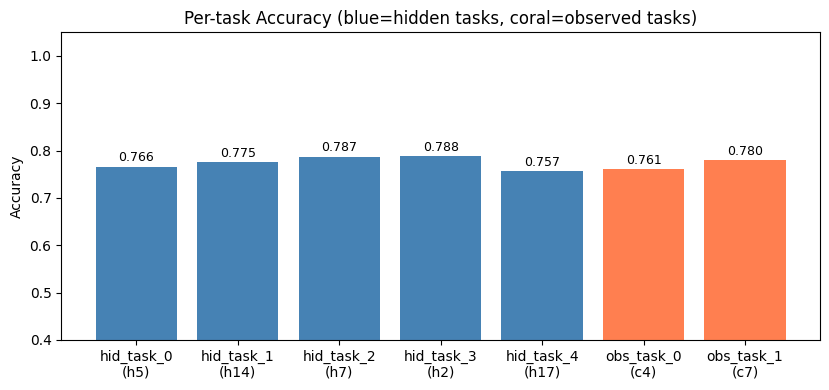

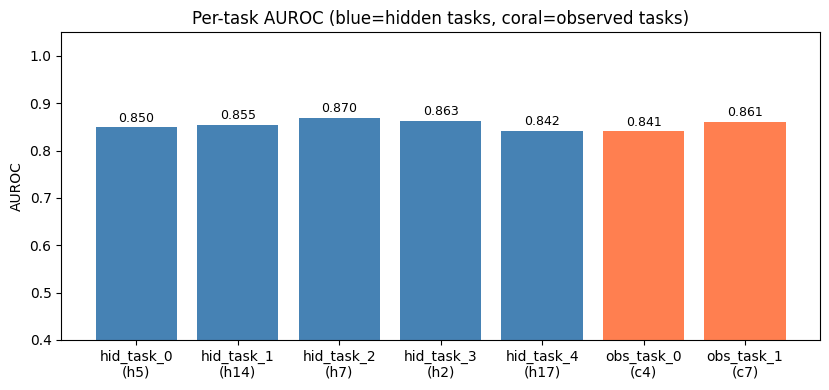

In [213]:
test_metrics = parse_test_metrics_multilabel(EXPERIMENT_PATH, num_tasks)

# Display summary
summary_df = pd.DataFrame([test_metrics])
display(summary_df[[c for c in summary_df.columns if "task" not in c]])

plot_per_task_metric(test_metrics, metric_name="y_accuracy_task")
plot_per_task_metric(test_metrics, metric_name="y_auroc_task")

In [214]:
print(test_data["s_hid"])
print(test_data["s_obs"])

print(f"Hidden task weights: {test_data['w_hid']}")
print(f"Observed task weights: {test_data['w_obs']}")

tensor([[-1.2675, -0.1150, -0.6321, -1.2644, -0.2467],
        [ 0.3846, -0.2260,  0.8732, -0.2223, -0.2278],
        [ 0.0625,  0.1126,  2.9607,  1.6316,  0.0601],
        ...,
        [ 2.5448,  1.2906,  1.0132,  3.7869,  0.2660],
        [ 1.0451,  0.0555,  1.6364,  1.3170,  0.5733],
        [-1.2307, -1.2313,  0.9990, -0.7174, -1.2331]])
tensor([[-0.8378, -0.8381],
        [ 1.7747, -0.4126],
        [ 2.1161,  0.4802],
        ...,
        [-0.9077,  3.4098],
        [-0.1447,  0.2178],
        [-0.3853, -0.3856]])
Hidden task weights: tensor([ 0.0000,  0.0000, -0.6096,  0.0000,  0.0000,  0.9749,  0.0000,  0.8919,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000, -0.9521,  0.0000,
         0.0000,  0.5495,  0.0000,  0.0000])
Observed task weights: tensor([0.0000, 0.6214, 0.0000, 0.0000, 0.9304, 0.0000, 0.0000, 0.8412, 0.0000,
        0.0000])


## SCBM performance

In [215]:
def get_scbm_model_path(full_experiment_path):
    full_experiment_path = str(full_experiment_path)
    relative_experiment_path = full_experiment_path.split("multilabel_synthetic/")[-1]
    # use re to find hid%d
    relative_experiment_path_list = relative_experiment_path.split("_")
    start_path = None


    for i, part in enumerate(relative_experiment_path_list):
        # hid tasks are always after the first part of the path, so we skip the first part 
        if part.startswith("hid") and i!=0:
            
            start_path =  "_".join(relative_experiment_path_list[:i+1])
            break
    #print(start_path)
    if start_path is None:
        return None
    
    scbm_root_dir = os.path.join("experiments", "scbm", "multilabel_synthetic")
    
    for dir in os.listdir(scbm_root_dir):
        if dir.startswith(start_path):
            return os.path.join(scbm_root_dir, dir)
    
scbm_full_path = get_scbm_model_path(EXPERIMENT_PATH)
print(f"SCBM model path: {scbm_full_path}")
if not scbm_full_path is None:
        
    scbm_test_metrics = parse_test_metrics_multilabel(scbm_full_path, num_tasks)
    plot_per_task_metric(scbm_test_metrics, metric_name="y_accuracy_task")
    plot_per_task_metric(scbm_test_metrics, metric_name="y_auroc_task")
    summary_df = pd.DataFrame([scbm_test_metrics])
    display(summary_df[[c for c in summary_df.columns if "task" not in c]])
    
else:
    print("No SCBM model found for this experiment.")



 

SCBM model path: None
No SCBM model found for this experiment.


## Linear head

In [216]:
import os
import re


def parse_test_metrics_linear_head(experiment_path, num_tasks: int):


    log_path = os.path.join(experiment_path, "log.txt")

    test_line = None
    with open(log_path, "r") as f:
        for line in f:
            if "Final Test Loss" in line:
                test_line = line.strip()

    if test_line is None:
        raise ValueError("No 'Final Test Loss' line found in log.txt")

    def get_metric(name, line=test_line, default=None):
        pattern = rf"{re.escape(name)}:\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)"
        m = re.search(pattern, line)
        return float(m.group(1)) if m else default

    metrics = {
        "y_hamming_accuracy": get_metric("Hamming Acc"),
        "y_macro_auroc": get_metric("Macro AUROC"),
        "y_exact_match": get_metric("Exact Match"),

        # Not present in this log format, but keeping keys for compatibility
        "y_macro_ap": None,
        "c_accuracy": None,
        "c_AUROC": None,
    }

    for k in range(num_tasks):
        metrics[f"y_auroc_task_{k}"] = get_metric(f"y_auroc_{k}")
        metrics[f"y_accuracy_task_{k}"] = get_metric(f"y_accuracy_{k}")

        # Not present in this log format
        metrics[f"y_ap_task_{k}"] = None

    return metrics


def get_linear_head_metrics(EXPERIMENT_PATH):
    data_dir_name = get_data_dir_name_from_log(EXPERIMENT_PATH)
    if data_dir_name is None:
        print("Could not find data_dir in log.txt")
        return

    
    linear_head_root_dir = os.path.join("experiments", "linear_head", "multilabel_synthetic")
    for dir in os.listdir(linear_head_root_dir):
        if dir.startswith(data_dir_name):
            linear_head_full_path = os.path.join(linear_head_root_dir, dir)
            linear_head_test_metrics = parse_test_metrics_linear_head(linear_head_full_path, num_tasks)
            summary_df = pd.DataFrame([linear_head_test_metrics])
            return linear_head_test_metrics
        
        
    
    print(f"data_dir_name: {data_dir_name}")
    



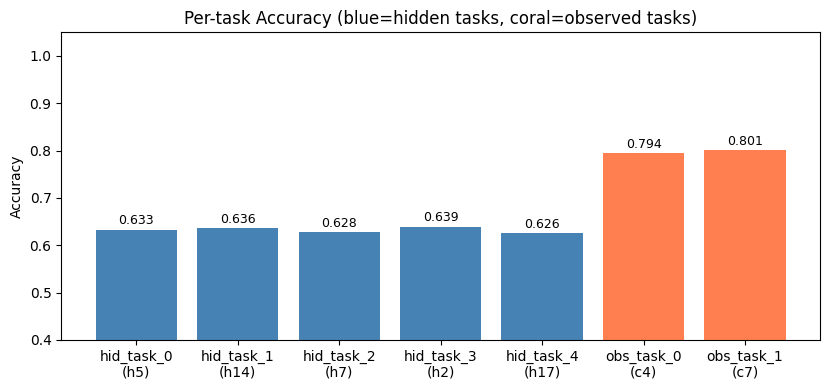

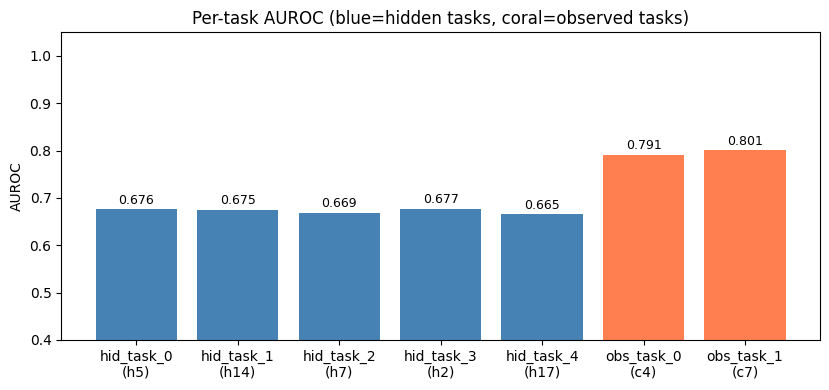

In [217]:
linear_head_metrics = get_linear_head_metrics(EXPERIMENT_PATH)
linear_head_metrics_df = pd.DataFrame([linear_head_metrics])
plot_per_task_metric(linear_head_metrics, metric_name="y_accuracy_task")
plot_per_task_metric(linear_head_metrics, metric_name="y_auroc_task")

## All model performance together

In [218]:
scbm_res_metrics = parse_test_metrics_multilabel(EXPERIMENT_PATH, num_tasks)
scbm_full_path = get_scbm_model_path(EXPERIMENT_PATH)
if not scbm_full_path is None:
        
    scbm_metrics = parse_test_metrics_multilabel(scbm_full_path, num_tasks)

else:
    print("No SCBM model found for this experiment.")
    
linear_head_metrics = get_linear_head_metrics(EXPERIMENT_PATH)
linear_head_metrics_df = pd.DataFrame([linear_head_metrics])
linear_head_metrics_df = linear_head_metrics_df[[c for c in linear_head_metrics_df.columns if "task" not in c]]

# Create df for all model performance metrics
all_metrics = {
    "Residual SCBM": scbm_res_metrics,
    "SCBM": scbm_metrics if not scbm_full_path is None else None,
    "Linear Head": linear_head_metrics
}

print(all_metrics)

all_metrics_df = pd.DataFrame(all_metrics).T
display(all_metrics_df[[c for c in all_metrics_df.columns if "task" not in c]])




No SCBM model found for this experiment.
{'Residual SCBM': {'y_macro_auroc': 0.855, 'y_macro_ap': 0.865, 'y_hamming_accuracy': 0.773, 'y_exact_match': 0.243, 'c_accuracy': 0.724, 'c_AUROC': 0.794, 'y_auroc_task_0': 0.85, 'y_accuracy_task_0': 0.766, 'y_ap_task_0': 0.86, 'y_auroc_task_1': 0.855, 'y_accuracy_task_1': 0.775, 'y_ap_task_1': 0.862, 'y_auroc_task_2': 0.87, 'y_accuracy_task_2': 0.787, 'y_ap_task_2': 0.882, 'y_auroc_task_3': 0.863, 'y_accuracy_task_3': 0.788, 'y_ap_task_3': 0.872, 'y_auroc_task_4': 0.842, 'y_accuracy_task_4': 0.757, 'y_ap_task_4': 0.854, 'y_auroc_task_5': 0.841, 'y_accuracy_task_5': 0.761, 'y_ap_task_5': 0.854, 'y_auroc_task_6': 0.861, 'y_accuracy_task_6': 0.78, 'y_ap_task_6': 0.873}, 'SCBM': None, 'Linear Head': {'y_hamming_accuracy': 0.6796, 'y_macro_auroc': 0.7079, 'y_exact_match': 0.1934, 'y_macro_ap': None, 'c_accuracy': None, 'c_AUROC': None, 'y_auroc_task_0': 0.6758, 'y_accuracy_task_0': 0.6329, 'y_ap_task_0': None, 'y_auroc_task_1': 0.6753, 'y_accuracy_

,y_macro_auroc,y_macro_ap,y_hamming_accuracy,y_exact_match,c_accuracy,c_AUROC
Residual SCBM,0.855,0.865,0.773,0.243,0.724,0.794
SCBM,None,None,None,None,None,None
Linear Head,0.7079,NaN,0.6796,0.1934,NaN,NaN


## Variance of hidden shared and observed shared

In [219]:
train_concept_signal = train_data["concept_signal"]
train_residual_signal = train_data["hidden_residual_signal"]

train_hidden_shared = train_residual_signal @ w_hid
train_observed_shared = train_concept_signal @ w_obs

print(f"train_hidden_shared var {train_hidden_shared.var().item():.4f}, train_observed_shared var {train_observed_shared.var().item():.4f}")

for i in train_data["obs_task_idx"]:
    specific_obs = train_concept_signal[:, i] * abs(w_obs[i])
    print(f"variance for observed signal {i}: {specific_obs.var().item():.4f}")



train_hidden_shared var 1.2531, train_observed_shared var 0.7347
variance for observed signal 4: 0.3231
variance for observed signal 7: 0.2652


## Per-task score verification

Verify that the s_hid and s_obs tensors from the dataset match the formula.

In [220]:
config = read_config_from_log(EXPERIMENT_PATH)
alpha = config["data"]["alpha"]
beta = config["data"]["beta"]

concept_signal = test_data["concept_signal"]  # (n, obs_dim)
residual_signal = test_data["hidden_residual_signal"]  # (n, hid_dim)

shared_obs_score = concept_signal  @ w_obs   # (n,)
shared_hid_score = residual_signal @ w_hid   # (n,)

s_hid_true = test_data["s_hid"]  # (n, K)
s_obs_true = test_data["s_obs"]  # (n, J)

print("Verifying hidden subtask scores:")
for k, idx in enumerate(hid_task_idx.tolist()):
    per_concept = residual_signal[:, idx] * float(w_hid[idx].abs())
    s_k = alpha * shared_obs_score + beta * per_concept
    diff = (s_k - s_hid_true[:, k]).abs()
    print(f"  task {k} (h{idx}): max_diff={diff.max():.2e}  mean_diff={diff.mean():.2e}")

print("\nVerifying observed subtask scores:")
for j, idx in enumerate(obs_task_idx.tolist()):
    per_concept = concept_signal[:, idx] * float(w_obs[idx].abs())
    s_j = alpha * per_concept + beta * shared_hid_score
    diff = (s_j - s_obs_true[:, j]).abs()
    print(f"  task {j} (c{idx}): max_diff={diff.max():.2e}  mean_diff={diff.mean():.2e}")


Verifying hidden subtask scores:
  task 0 (h5): max_diff=3.96e+00  mean_diff=1.31e+00
  task 1 (h14): max_diff=3.96e+00  mean_diff=1.31e+00
  task 2 (h7): max_diff=5.00e+00  mean_diff=1.31e+00
  task 3 (h2): max_diff=3.57e+00  mean_diff=1.31e+00
  task 4 (h17): max_diff=3.90e+00  mean_diff=1.30e+00

Verifying observed subtask scores:
  task 0 (c4): max_diff=1.78e+00  mean_diff=6.53e-01
  task 1 (c7): max_diff=1.88e+00  mean_diff=6.57e-01


## Distributed probe — hidden concept recovery

Logistic regression on the full `res_mu` vector to predict each hidden concept. This is the upper bound on recoverable hidden-concept information from the residual channel. Task-bit concepts (hid_task_idx) should show high AUC; non-task-bit concepts should be near chance.

Hidden concept distributed probe (task bits highlighted):


,hidden_concept_idx,distributed_auc,distributed_accuracy,distributed_f1,w_hid,abs_w_hid,is_task_bit,hid_task_k
5,5,0.755485,0.6875,0.680829,0.974940,0.974940,True,0.0
14,14,0.757699,0.6905,0.684280,-0.952066,0.952066,True,1.0
7,7,0.790261,0.7183,0.709318,0.891934,0.891934,True,2.0
2,2,0.769360,0.7034,0.688903,-0.609588,0.609588,True,3.0
17,17,0.744712,0.6814,0.673833,0.549488,0.549488,True,4.0
0,0,0.597496,0.5688,0.572137,0.000000,0.000000,False,NaN
12,12,0.584858,0.5600,0.558233,0.000000,0.000000,False,NaN
18,18,0.581609,0.5604,0.562935,0.000000,0.000000,False,NaN
16,16,0.580656,0.5543,0.562138,0.000000,0.000000,False,NaN
15,15,0.579665,0.5626,0.558093,0.000000,0.000000,False,NaN


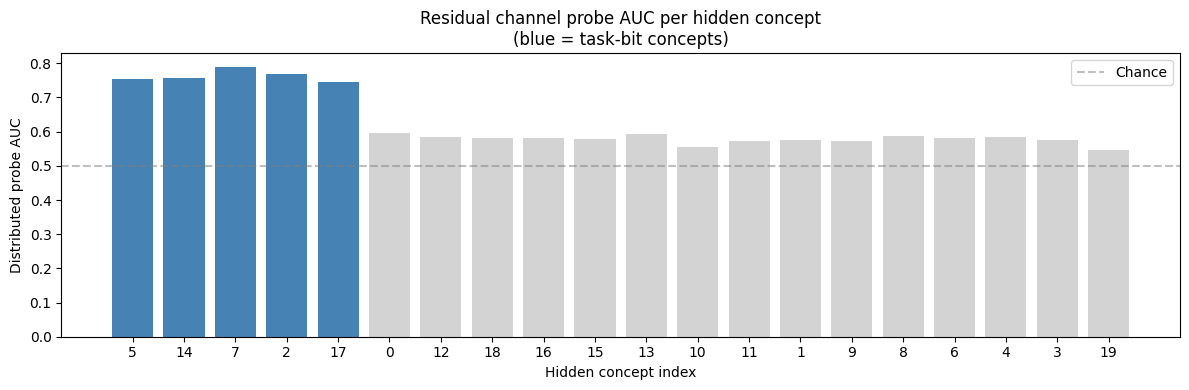

In [221]:
def probe_baseline(H_pred_train, H_true_train, H_pred_test, H_true_test,
                   column_name="hidden_concept_idx"):
    """Fit one logistic regression per column of H_true, evaluate on test set."""
    H_pred_train = to_numpy(H_pred_train).astype(float)
    H_pred_test = to_numpy(H_pred_test).astype(float)
    H_true_train = to_numpy(H_true_train).astype(float)
    H_true_test = to_numpy(H_true_test).astype(float)

    rows = []
    for h in range(H_true_train.shape[1]):
        clf = make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=1000, class_weight="balanced", random_state=0),
        )
        clf.fit(H_pred_train, H_true_train[:, h])
        probs = clf.predict_proba(H_pred_test)[:, 1]
        preds = (probs >= 0.5).astype(int)
        rows.append({
            column_name: h,
            "distributed_auc": roc_auc_score(H_true_test[:, h], probs),
            "distributed_accuracy": accuracy_score(H_true_test[:, h], preds),
            "distributed_f1": f1_score(H_true_test[:, h], preds),
        })
    return pd.DataFrame(rows)


# Hidden concepts from res_mu
probe_hidden = probe_baseline(
    splits["train"]["res_mu"], splits["train"]["hidden_residuals"],
    splits["test"]["res_mu"], splits["test"]["hidden_residuals"],
)

# Annotate with task weights and task membership
probe_hidden["w_hid"] = probe_hidden["hidden_concept_idx"].apply(lambda i: w_hid[i].item())
probe_hidden["abs_w_hid"] = probe_hidden["w_hid"].abs()
probe_hidden["is_task_bit"]= probe_hidden["hidden_concept_idx"].isin(hid_task_idx.tolist())
probe_hidden["hid_task_k"] = probe_hidden["hidden_concept_idx"].map(task_map_hid)
probe_hidden = probe_hidden.sort_values("abs_w_hid", ascending=False)

print("Hidden concept distributed probe (task bits highlighted):")
display(probe_hidden.head(20))

# Bar chart: probe AUC per hidden concept, coloured by task membership
fig, ax = plt.subplots(figsize=(max(8, hid_dim * 0.6), 4))
colors_bar = ["steelblue" if is_tb else "lightgrey"
              for is_tb in probe_hidden["is_task_bit"]]
ax.bar(probe_hidden["hidden_concept_idx"].astype(str), probe_hidden["distributed_auc"],
       color=colors_bar)
ax.axhline(0.5, color="grey", linestyle="--", alpha=0.5, label="Chance")
ax.set_xlabel("Hidden concept index")
ax.set_ylabel("Distributed probe AUC")
ax.set_title("Residual channel probe AUC per hidden concept\n(blue = task-bit concepts)")
ax.legend()
plt.tight_layout()
plt.show()


## Observed concept probe — ceiling reference

Logistic regression on `c_mu` to predict each observed concept. Provides the AUC ceiling: the residual task-bit probe should approach this.

Observed concept probe (task bits highlighted):


,concept_idx,distributed_auc,distributed_accuracy,distributed_f1,w_obs,abs_w_obs,is_task_bit
4,4,0.785745,0.7161,0.709565,0.930378,0.930378,True
7,7,0.806505,0.7324,0.725369,0.841165,0.841165,True
1,1,0.803044,0.7268,0.716656,0.621388,0.621388,False
0,0,0.782115,0.7112,0.698161,0.000000,0.000000,False
2,2,0.775486,0.7036,0.695187,0.000000,0.000000,False
3,3,0.798385,0.7250,0.716261,0.000000,0.000000,False
5,5,0.797354,0.7238,0.720275,0.000000,0.000000,False
6,6,0.815527,0.7372,0.730074,0.000000,0.000000,False
8,8,0.792974,0.7174,0.712513,0.000000,0.000000,False
9,9,0.796566,0.7262,0.715975,0.000000,0.000000,False


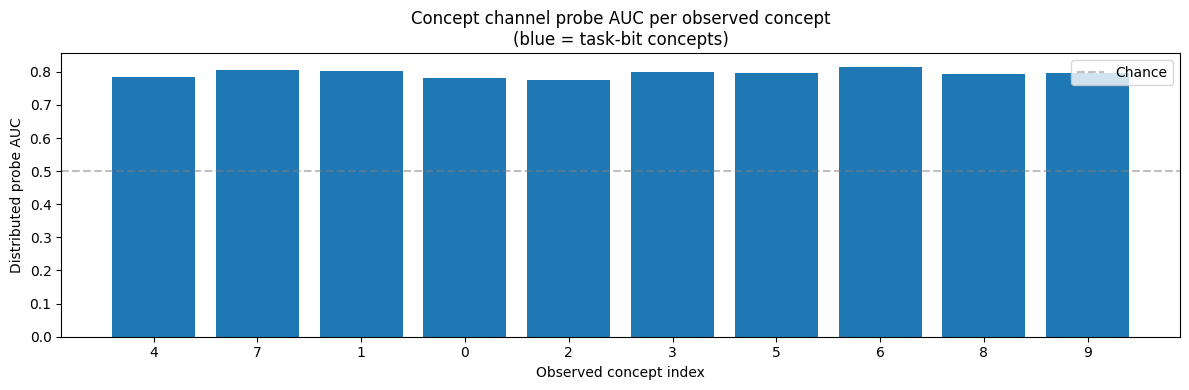

In [222]:
probe_observed = probe_baseline(
    splits["train"]["c_mu"], splits["train"]["concepts"],
    splits["test"]["c_mu"], splits["test"]["concepts"],
    column_name="concept_idx",
)
probe_observed["w_obs"] = probe_observed["concept_idx"].apply(lambda i: w_obs[i].item())
probe_observed["abs_w_obs"] = probe_observed["w_obs"].abs()
probe_observed["is_task_bit"]= probe_observed["concept_idx"].isin(obs_task_idx.tolist())
probe_observed = probe_observed.sort_values("abs_w_obs", ascending=False)

print("Observed concept probe (task bits highlighted):")
display(probe_observed)

# Bar chart: probe AUC per hidden concept, coloured by task membership
fig, ax = plt.subplots(figsize=(max(8, hid_dim * 0.6), 4))

ax.bar(probe_observed["concept_idx"].astype(str), probe_observed["distributed_auc"])
ax.axhline(0.5, color="grey", linestyle="--", alpha=0.5, label="Chance")
ax.set_xlabel("Observed concept index")
ax.set_ylabel("Distributed probe AUC")
ax.set_title("Concept channel probe AUC per observed concept\n(blue = task-bit concepts)")
ax.legend()
plt.tight_layout()
plt.show()


## MLP from raw x → hidden concepts / observed concepts

Upper bound: how much hidden-concept information is in x with a nonlinear model. If MLP AUC >> probe AUC for task-bit concepts, the residual channel is leaving signal on the table.

In [223]:
class ConceptMLP(nn.Module):
    def __init__(self, input_dim, num_outputs, hidden_dims=(128, 64), dropout=0.1):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, num_outputs))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)


def evaluate_mlp(model, loader, device):
    model.eval()
    all_logits, all_targets = [], []
    with torch.no_grad():
        for xb, yb in loader:
            all_logits.append(model(xb.to(device)).cpu())
            all_targets.append(yb)
    logits = torch.cat(all_logits)
    targets = torch.cat(all_targets)
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float()

    per_col = []
    for j in range(targets.shape[1]):
        y_true = to_numpy(targets[:, j])
        y_prob = to_numpy(probs[:, j])
        y_pred = to_numpy(preds[:, j])
        row = {"col_idx": j,
               "accuracy": accuracy_score(y_true, y_pred),
               "f1": f1_score(y_true, y_pred, zero_division=0)}
        if len(np.unique(y_true)) > 1:
            row["auc"] = roc_auc_score(y_true, y_prob)
        else:
            row["auc"] = np.nan
        per_col.append(row)
    per_col_df = pd.DataFrame(per_col)

    return {
        "macro_auc": float(np.nanmean(per_col_df["auc"])),
        "hamming_acc": (preds == targets).float().mean().item(),
        "exact_match": (preds == targets).all(dim=1).float().mean().item(),
        "macro_f1": float(np.nanmean(per_col_df["f1"])),
    }, per_col_df


def train_mlp_from_x(train_data, val_data, test_data, target_key,
                     hidden_dims=(128, 64), dropout=0.1, lr=1e-3,
                     weight_decay=1e-4, batch_size=512, epochs=100, patience=10):
    device = torch.device("cpu")
    x_mean = train_data["x"].float().mean(0, keepdim=True)
    x_std = train_data["x"].float().std(0, keepdim=True).clamp_min(1e-6)

    def normalize_x(data):
        data = data.copy()
        data["x"] = (data["x"].float() - x_mean) / x_std
        return data

    tr = normalize_x(train_data)
    va = normalize_x(val_data)
    te = normalize_x(test_data)
    


    def loader(split, shuffle=False):
        ds = torch.utils.data.TensorDataset(split["x"], split[target_key].float())
        return torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

    model = ConceptMLP(tr["x"].shape[1], tr[target_key].shape[1],
                       hidden_dims=hidden_dims, dropout=dropout).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val, best_state, epochs_no_improve = -float("inf"), None, 0
    for epoch in range(1, epochs + 1):
        model.train()
        for xb, yb in loader(tr, shuffle=True):
            opt.zero_grad()
            F.binary_cross_entropy_with_logits(model(xb.to(device)), yb.to(device)).backward()
            opt.step()
        val_metrics, _ = evaluate_mlp(model, loader(va), device)
        if val_metrics["macro_auc"] > best_val:
            best_val = val_metrics["macro_auc"]
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break

    model.load_state_dict(best_state)
    test_metrics, per_col_df = evaluate_mlp(model, loader(te), device)
    return test_metrics, per_col_df





In [224]:
print("Training MLP(x → hidden concepts) — upper bound on recoverable information...")
mlp_hid_metrics, mlp_hid_per_col = train_mlp_from_x(
    train_data, val_data, test_data, target_key="hidden_residuals"
)
mlp_hid_per_col["is_task_bit"] = mlp_hid_per_col["col_idx"].isin(hid_task_idx.tolist())
mlp_hid_per_col["hid_task_k"] = mlp_hid_per_col["col_idx"].map(task_map_hid)
print("MLP(x → hidden) aggregate:", mlp_hid_metrics)
display(mlp_hid_per_col)


Training MLP(x → hidden concepts) — upper bound on recoverable information...
MLP(x → hidden) aggregate: {'macro_auc': 0.814357920404875, 'hamming_acc': 0.7404000163078308, 'exact_match': 0.0015999999595806003, 'macro_f1': 0.7279276429576551}


,col_idx,accuracy,f1,auc,is_task_bit,hid_task_k
0,0,0.7523,0.732650,0.822735,False,NaN
1,1,0.7451,0.726531,0.817325,False,NaN
2,2,0.7428,0.724094,0.813777,True,3.0
3,3,0.7600,0.739244,0.832970,False,NaN
4,4,0.7213,0.708015,0.794553,False,NaN
5,5,0.7232,0.713813,0.800830,True,0.0
6,6,0.7469,0.734613,0.820724,False,NaN
7,7,0.7618,0.749579,0.833707,True,2.0
8,8,0.7230,0.713191,0.798082,False,NaN
9,9,0.7211,0.721184,0.798795,False,NaN


In [225]:
print("Training MLP(x → observed concepts) — upper bound on recoverable information...")
mlp_obs_metrics, mlp_obs_per_col = train_mlp_from_x(
    train_data, val_data, test_data, target_key="concepts"
)
mlp_obs_per_col["is_task_bit"] = mlp_obs_per_col["col_idx"].isin(obs_task_idx.tolist())
mlp_obs_per_col["obs_task_k"] = mlp_obs_per_col["col_idx"].map(task_map_obs)
print("MLP(x → observed) aggregate:", mlp_obs_metrics)
display(mlp_obs_per_col)


Training MLP(x → observed concepts) — upper bound on recoverable information...
MLP(x → observed) aggregate: {'macro_auc': 0.8141858242353202, 'hamming_acc': 0.7407000064849854, 'exact_match': 0.04769999906420708, 'macro_f1': 0.7232680357114216}


,col_idx,accuracy,f1,auc,is_task_bit,obs_task_k
0,0,0.7313,0.712712,0.804379,False,NaN
1,1,0.7479,0.730749,0.818968,False,NaN
2,2,0.7205,0.707605,0.797449,False,NaN
3,3,0.7437,0.724260,0.815778,False,NaN
4,4,0.7374,0.722586,0.810654,True,0.0
5,5,0.7434,0.730462,0.815338,False,NaN
6,6,0.7577,0.738647,0.831308,False,NaN
7,7,0.7492,0.724940,0.824583,True,1.0
8,8,0.7340,0.713177,0.807199,False,NaN
9,9,0.7419,0.727541,0.816203,False,NaN


## Raw axis AUC matrix — hidden concepts vs residual dimensions

Each cell = AUC of residual dimension r_j for predicting hidden concept h_i. Task-bit rows (hid_task_idx) should show elevated AUC; other rows should be ~0.5.

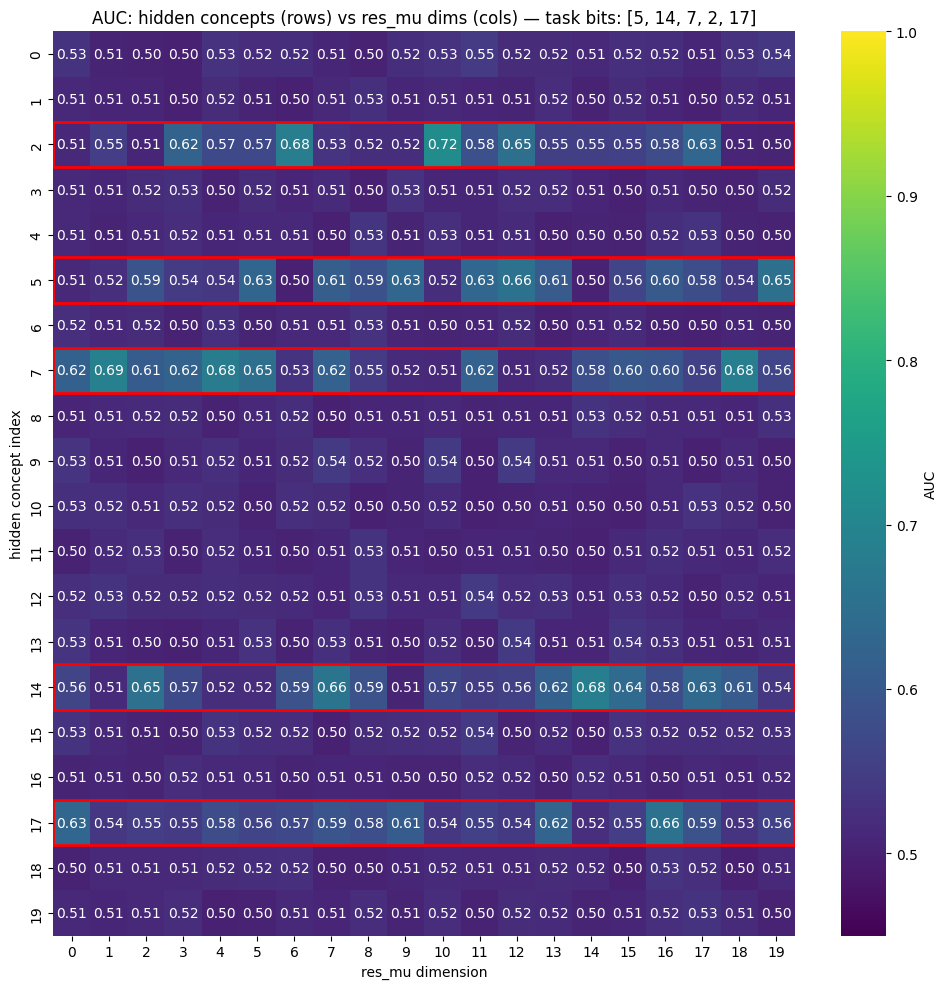

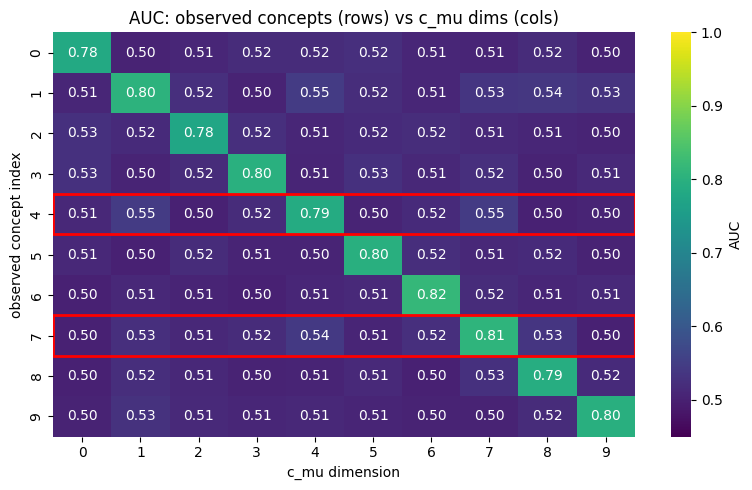

In [226]:
def auc_matrix(true_labels, pred_scores):
    """Compute AUC for every (row, col) pair. Shape: (n_true, n_pred)."""
    n_true = true_labels.shape[1]
    n_pred = pred_scores.shape[1]
    mat = np.zeros((n_true, n_pred))
    for i in range(n_true):
        for j in range(n_pred):
            if len(np.unique(true_labels[:, i])) > 1:
                mat[i, j] = calculate_auc(true_labels[:, i], pred_scores[:, j])
            else:
                mat[i, j] = np.nan
    return mat


def plot_heatmap(mat, title, x_label, y_label, annot=True,
                 highlight_rows=None, highlight_cols=None):
    fig, ax = plt.subplots(figsize=(max(8, mat.shape[1] * 0.5),
                                    max(5, mat.shape[0] * 0.5)))
    sns.heatmap(mat, annot=annot, fmt=".2f", cmap="viridis",
                vmin=0.45, vmax=1.0, ax=ax, cbar_kws={"label": "AUC"})
    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    if highlight_rows is not None:
        for r in highlight_rows:
            ax.add_patch(plt.Rectangle((0, r), mat.shape[1], 1,
                         fill=False, edgecolor="red", lw=2))
    plt.tight_layout()
    plt.show()


# Hidden concepts vs residual dimensions
auc_mat_hid_res = auc_matrix(
    to_numpy(test_data["hidden_residuals"]),
    to_numpy(test_data["res_mu"]),
)
plot_heatmap(
    auc_mat_hid_res,
    title=f"AUC: hidden concepts (rows) vs res_mu dims (cols) — task bits: {hid_task_idx.tolist()}",
    x_label="res_mu dimension",
    y_label="hidden concept index",
    highlight_rows=hid_task_idx.tolist(),
    annot=True,
)

# Observed concepts vs c_mu (ceiling reference)
auc_mat_obs_cmu = auc_matrix(
    to_numpy(test_data["concepts"]),
    to_numpy(test_data["c_mu"]),
)
plot_heatmap(
    auc_mat_obs_cmu,
    title="AUC: observed concepts (rows) vs c_mu dims (cols)",
    x_label="c_mu dimension",
    y_label="observed concept index",
    highlight_rows=obs_task_idx.tolist(),
    annot=True,
)


## SVD — effective rank of residual channel

With K hidden subtasks the residual channel should collapse to a ~K-dimensional subspace. Check cumulative explained variance: expect ~K significant singular values.

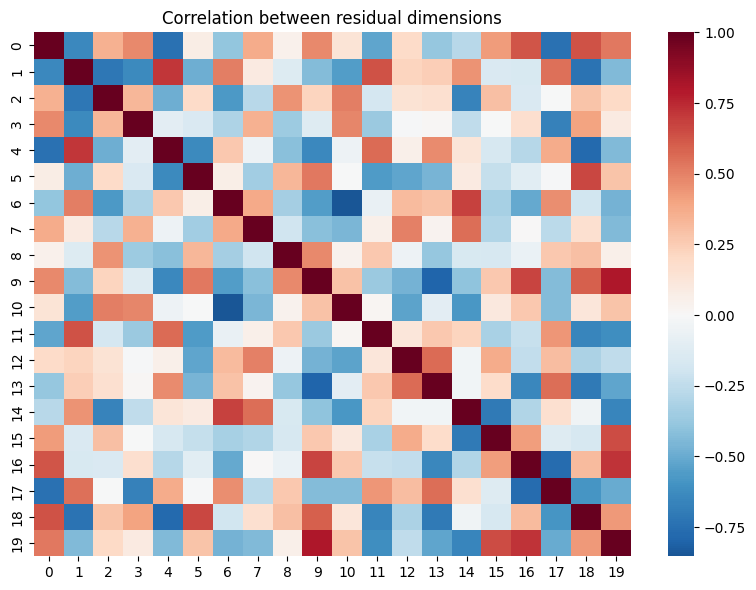

Variance explained by each residual axis:


,axis,singular_value,explained_variance,explained_variance_%,cumulative_variance_%
0,1,1157.288330,0.3553,35.525101,35.525101
1,2,785.570618,0.1637,16.368999,51.894199
2,3,757.609009,0.1522,15.224500,67.118698
3,4,652.940002,0.1131,11.308300,78.427002
4,5,630.953186,0.1056,10.559600,88.986603
5,6,550.246887,0.0803,8.031000,97.017601
6,7,280.256989,0.0208,2.083400,99.100899
7,8,78.798302,0.0016,0.164700,99.265602
8,9,71.565201,0.0014,0.135800,99.401497
9,10,60.499500,0.0010,0.097100,99.498596


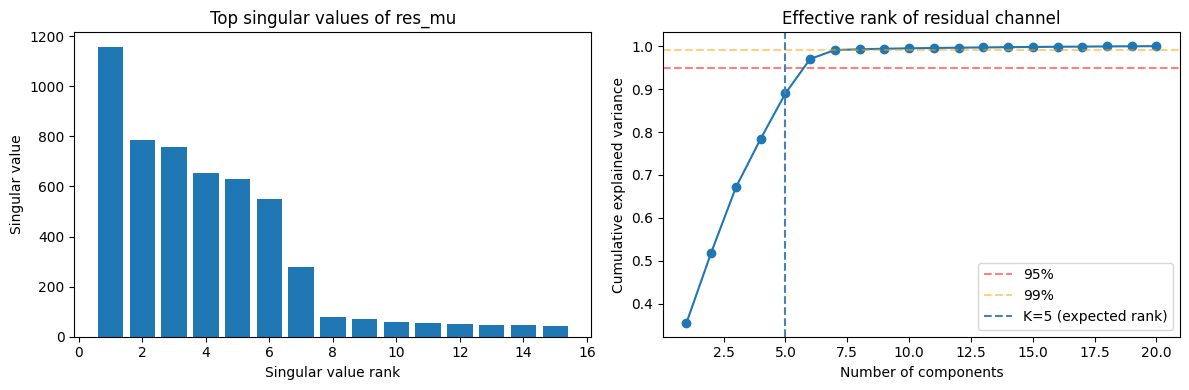

Expected effective rank (num_hid_tasks K): 5
Variance explained by top-K components: 0.8899
Variance explained by top-1: 0.3553
Top singular values: [1157.3  785.6  757.6  652.9  631.   550.2  280.3]


In [227]:
R = to_numpy(test_data["res_mu"])
R_centered = R - R.mean(axis=0)

corr = np.corrcoef(R_centered.T)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, center=0, ax=ax, cmap="RdBu_r")
ax.set_title("Correlation between residual dimensions")
plt.tight_layout()
plt.show()

u, s, vh = np.linalg.svd(R_centered, full_matrices=False)
explained = s**2 / np.sum(s**2)
cumvar = np.cumsum(explained)

axis_variance = pd.DataFrame({
    "axis": np.arange(1, len(explained) + 1),
    "singular_value": s,
    "explained_variance": explained,
    "explained_variance_%": 100 * explained,
    "cumulative_variance_%": 100 * cumvar,
})
print("Variance explained by each residual axis:")
display(axis_variance.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(np.arange(1, len(s[:15])+1), s[:15])
axes[0].set_xlabel("Singular value rank")
axes[0].set_ylabel("Singular value")
axes[0].set_title("Top singular values of res_mu")

axes[1].plot(np.arange(1, len(cumvar)+1), cumvar, marker="o")
axes[1].axhline(0.95, color="red", linestyle="--", alpha=0.5, label="95%")
axes[1].axhline(0.99, color="orange", linestyle="--", alpha=0.5, label="99%")
# Mark expected effective rank = num_hid_tasks
axes[1].axvline(num_hid_tasks, color="steelblue", linestyle="--",
                label=f"K={num_hid_tasks} (expected rank)")
axes[1].set_xlabel("Number of components")
axes[1].set_ylabel("Cumulative explained variance")
axes[1].set_title("Effective rank of residual channel")
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"Expected effective rank (num_hid_tasks K): {num_hid_tasks}")
print(f"Variance explained by top-K components: {cumvar[num_hid_tasks-1]:.4f}")
print(f"Variance explained by top-1: {cumvar[0]:.4f}")
print(f"Top singular values: {s[:num_hid_tasks+2].round(1)}")


## PCA alignment — do principal components align with task-bit hidden concepts?

With K subtasks, expect PC1..PCK to each align strongly with one task-bit hidden concept. Non-task-bit concepts should show near-chance AUC with all PCs.

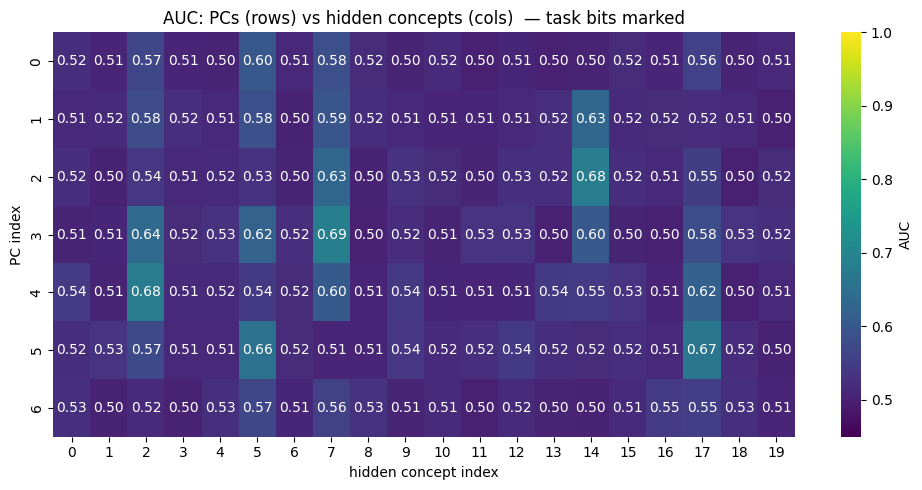

Best hidden concept alignment per PC:


,pc,hidden_concept_idx,auc,explained_variance,is_task_bit
0,1,5,0.599542,0.355252,True
1,2,14,0.631444,0.163690,True
2,3,14,0.680717,0.152245,True
3,4,7,0.685744,0.113084,True
4,5,2,0.675764,0.105596,True
5,6,17,0.665349,0.080310,True
6,7,5,0.567916,0.020834,True


In [228]:
n_pc = min(num_hid_tasks + 2, num_residuals)
pca = PCA(n_components=n_pc)
Z = pca.fit_transform(R_centered)  # (n, n_pc)

H = to_numpy(test_data["hidden_residuals"])

rows = []
for pc_idx in range(n_pc):
    for h_idx in range(H.shape[1]):
        auc = calculate_auc(H[:, h_idx], Z[:, pc_idx])
        rows.append({
            "pc": pc_idx + 1,
            "hidden_concept_idx": h_idx,
            "auc": auc,
            "explained_variance": pca.explained_variance_ratio_[pc_idx],
            "is_task_bit": h_idx in hid_task_idx.tolist(),
        })

pc_df = pd.DataFrame(rows)

# Heatmap: PC (rows) x hidden concept (cols) — AUC
pc_hid_mat = pc_df.pivot(index="pc", columns="hidden_concept_idx", values="auc").values

plot_heatmap(
    pc_hid_mat,
    title="AUC: PCs (rows) vs hidden concepts (cols)  — task bits marked",
    x_label="hidden concept index",
    y_label="PC index",
    highlight_cols=hid_task_idx.tolist(),
    annot=True,
)

# Per-PC: best hidden concept alignment
best_per_pc = pc_df.sort_values("auc", ascending=False).groupby("pc").first().reset_index()
print("Best hidden concept alignment per PC:")
display(best_per_pc[["pc", "hidden_concept_idx", "auc", "explained_variance", "is_task_bit"]])


## Lasso decomposition — which hidden concepts drive each PC?

Fit Lasso(hidden_concept_signals → PC_k) for each of the top K PCs. Coefficients should concentrate on the task-bit hidden concepts.

In [229]:
H_signal = to_numpy(test_data["hidden_residual_signal"])  # (n, hid_dim)

lasso_rows = []
for pc_idx in range(num_hid_tasks):
    pc_vec = Z[:, pc_idx]
    lasso = make_pipeline(StandardScaler(), Lasso(alpha=0.001, max_iter=10000))
    lasso.fit(H_signal, pc_vec)
    coefs = lasso.named_steps["lasso"].coef_
    r2 = r2_score(pc_vec, lasso.predict(H_signal))
    for h_idx, coef in enumerate(coefs):
        lasso_rows.append({
            "pc": pc_idx + 1,
            "hidden_concept_idx": h_idx,
            "coef": coef,
            "abs_coef": abs(coef),
            "w_hid": w_hid[h_idx].item(),
            "abs_w_hid": w_hid[h_idx].abs().item(),
            "is_task_bit": h_idx in hid_task_idx.tolist(),
            "r2": r2,
        })

lasso_df = pd.DataFrame(lasso_rows)

for pc_idx in range(num_hid_tasks):
    sub = lasso_df[lasso_df["pc"] == pc_idx + 1].sort_values("abs_coef", ascending=False)
    r2 = sub["r2"].iloc[0]
    print(f"PC{pc_idx+1}  R²={r2:.3f}  — top coefficients:")
    display(sub[sub["abs_coef"] > 1e-4][
        ["hidden_concept_idx", "coef", "abs_coef", "w_hid", "is_task_bit"]
    ].head(8))
    print()


PC1  R²=0.137  — top coefficients:


,hidden_concept_idx,coef,abs_coef,w_hid,is_task_bit
5,5,-2.513976,2.513976,0.974940,True
7,7,-2.295710,2.295710,0.891934,True
2,2,-1.602830,1.602830,-0.609588,True
17,17,-1.566775,1.566775,0.549488,True
15,15,0.813762,0.813762,0.000000,False
0,0,0.600603,0.600603,0.000000,False
18,18,0.491003,0.491003,0.000000,False
12,12,0.340306,0.340306,0.000000,False



PC2  R²=0.253  — top coefficients:


,hidden_concept_idx,coef,abs_coef,w_hid,is_task_bit
34,14,2.463585,2.463585,-0.952066,True
27,7,-1.879420,1.879420,0.891934,True
22,2,1.583008,1.583008,-0.609588,True
25,5,-1.495897,1.495897,0.974940,True
23,3,0.470224,0.470224,0.000000,False
33,13,-0.469136,0.469136,0.000000,False
37,17,-0.368026,0.368026,0.549488,True
28,8,0.364458,0.364458,0.000000,False



PC3  R²=0.361  — top coefficients:


,hidden_concept_idx,coef,abs_coef,w_hid,is_task_bit
54,14,3.358247,3.358247,-0.952066,True
47,7,-2.575238,2.575238,0.891934,True
57,17,-0.739390,0.739390,0.549488,True
42,2,0.653445,0.653445,-0.609588,True
49,9,-0.535456,0.535456,0.000000,False
52,12,0.470696,0.470696,0.000000,False
40,0,0.467697,0.467697,0.000000,False
45,5,0.413583,0.413583,0.974940,True



PC4  R²=0.552  — top coefficients:


,hidden_concept_idx,coef,abs_coef,w_hid,is_task_bit
67,7,-2.902372,2.902372,0.891934,True
62,2,2.105153,2.105153,-0.609588,True
65,5,2.044919,2.044919,0.974940,True
74,14,-1.784671,1.784671,-0.952066,True
77,17,1.317481,1.317481,0.549488,True
72,12,0.635342,0.635342,0.000000,False
78,18,-0.516134,0.516134,0.000000,False
66,6,-0.464383,0.464383,0.000000,False



PC5  R²=0.472  — top coefficients:


,hidden_concept_idx,coef,abs_coef,w_hid,is_task_bit
82,2,-3.041711,3.041711,-0.609588,True
97,17,2.086232,2.086232,0.549488,True
87,7,-1.620589,1.620589,0.891934,True
94,14,0.737173,0.737173,-0.952066,True
85,5,0.654061,0.654061,0.974940,True
80,0,-0.622426,0.622426,0.000000,False
89,9,0.609202,0.609202,0.000000,False
93,13,-0.577758,0.577758,0.000000,False


## Per-task score alignment — do PC_k align with s_hid_k?

s_hid[:, k] is the continuous score that determines task k's label. The residual channel should organise so that some direction correlates strongly with each s_hid_k.

Correlation between top PCs and per-task hidden scores (s_hid_k):


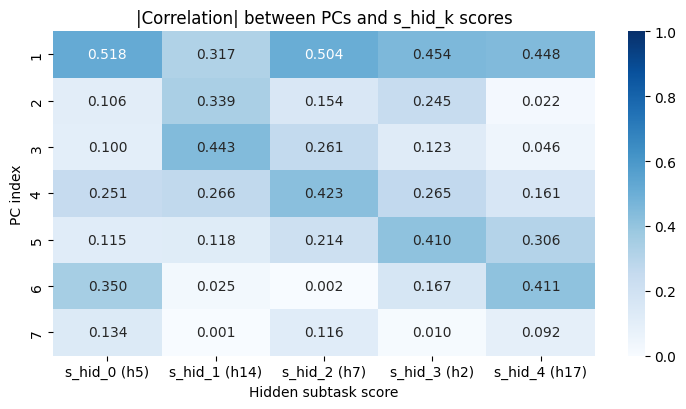


AUC between top PCs and binary task labels:


task,0,1,2,3,4,5,6
pc,,,,,,,
1,0.791,0.693,0.781,0.760,0.752,0.751,0.749
2,0.548,0.656,0.561,0.608,0.505,0.505,0.754
3,0.551,0.692,0.606,0.564,0.515,0.705,0.526
4,0.599,0.609,0.681,0.602,0.560,0.505,0.520
5,0.549,0.549,0.592,0.654,0.624,0.558,0.508
6,0.637,0.511,0.507,0.566,0.657,0.568,0.513
7,0.542,0.526,0.535,0.511,0.524,0.530,0.537


In [230]:
s_hid_np = to_numpy(test_data["s_hid"])  # (n, K)

print("Correlation between top PCs and per-task hidden scores (s_hid_k):")
corr_rows = []
for pc_idx in range(n_pc):
    for k in range(num_hid_tasks):
        corr = np.corrcoef(Z[:, pc_idx], s_hid_np[:, k])[0, 1]
        corr_rows.append({"pc": pc_idx + 1, "hid_task_k": k, "correlation": corr,
                          "hid_concept": hid_task_idx[k].item()})
corr_df = pd.DataFrame(corr_rows)
corr_mat = corr_df.pivot(index="pc", columns="hid_task_k", values="correlation")
corr_mat.columns = [f"s_hid_{k} (h{hid_task_idx[k].item()})" for k in corr_mat.columns]

fig, ax = plt.subplots(figsize=(max(5, num_hid_tasks * 1.5), max(4, n_pc * 0.6)))
sns.heatmap(corr_mat.abs(), annot=True, fmt=".3f", cmap="Blues",
            vmin=0, vmax=1, ax=ax)
ax.set_title("|Correlation| between PCs and s_hid_k scores")
ax.set_xlabel("Hidden subtask score")
ax.set_ylabel("PC index")
plt.tight_layout()
plt.show()

# Also check correlation with y columns (binary labels)
y_np = to_numpy(test_data["y"])  # (n, K+J)
print("\nAUC between top PCs and binary task labels:")
auc_rows = []
for pc_idx in range(n_pc):
    for t in range(num_tasks):
        label = "hid" if t < num_hid_tasks else "obs"
        auc = calculate_auc(y_np[:, t], Z[:, pc_idx])
        auc_rows.append({"pc": pc_idx + 1, "task": t, "label_type": label, "auc": auc})
auc_task_df = pd.DataFrame(auc_rows)
display(auc_task_df.pivot(index="pc", columns="task", values="auc").round(3))


## Concept channel — does c_mu align with observed subtask scores?

The observed subtask (J tasks) should be recoverable from c_mu. This mirrors the hidden task analysis but for the concept encoder.

In [231]:
s_obs_np = to_numpy(test_data["s_obs"])  # (n, J)
C_mu = to_numpy(test_data["c_mu"])

pca_c = PCA(n_components=min(num_obs_tasks + 2, num_concepts))
Z_c = pca_c.fit_transform(C_mu - C_mu.mean(0))

print("Correlation between top concept PCs and s_obs_j scores:")
obs_corr_rows = []
for pc_idx in range(Z_c.shape[1]):
    for j in range(num_obs_tasks):
        corr = np.corrcoef(Z_c[:, pc_idx], s_obs_np[:, j])[0, 1]
        obs_corr_rows.append({
            "pc": pc_idx + 1,
            "obs_task_j": j,
            "correlation": corr,
            "obs_concept": obs_task_idx[j].item(),
        })
obs_corr_df = pd.DataFrame(obs_corr_rows)
obs_corr_mat = obs_corr_df.pivot(index="pc", columns="obs_task_j", values="correlation")
obs_corr_mat.columns = [f"s_obs_{j} (c{obs_task_idx[j].item()})" for j in obs_corr_mat.columns]
display(obs_corr_mat.abs().round(3))


Correlation between top concept PCs and s_obs_j scores:


,s_obs_0 (c4),s_obs_1 (c7)
pc,,
1,0.044,0.379
2,0.394,0.352
3,0.333,0.035
4,0.130,0.203


## Correlation c_mu and s_obs

In [232]:
# correlation between c_mu and s_obs_j
print("\nCorrelation between c_mu dimensions and s_obs_j scores:")
corr_rows = []
print(f"C_mu shape: {C_mu.shape}, s_obs shape: {s_obs_np.shape}")



for c_idx in range(C_mu.shape[1]):
    for j in range(num_obs_tasks):
        corr = np.corrcoef(C_mu[:, c_idx], s_obs_np[:, j])[0, 1]
        corr_rows.append({
            "c_mu_dim": c_idx,
            "obs_task_j": j,
            "correlation": corr,
            "obs_concept": obs_task_idx[j].item(),
        })
corr_df = pd.DataFrame(corr_rows)
corr_mat = corr_df.pivot(index="c_mu_dim", columns="obs_task_j", values="correlation")
corr_mat.columns = [f"s_obs_{j} (c{obs_task_idx[j].item()})" for j in corr_mat.columns]
display(corr_mat.abs().round(3))


Correlation between c_mu dimensions and s_obs_j scores:
C_mu shape: (10000, 10), s_obs shape: (10000, 2)


,s_obs_0 (c4),s_obs_1 (c7)
c_mu_dim,,
0,0.003,0.005
1,0.061,0.056
2,0.004,0.021
3,0.013,0.033
4,0.679,0.048
5,0.017,0.034
6,0.021,0.028
7,0.075,0.711
8,0.029,0.067


## Correlation r_mu and s_hid

In [233]:
# correlation between r_mu and s_hid_j
R_mu = to_numpy(test_data["res_mu"])  # (n, R)
print("\nCorrelation between r_mu dimensions and s_hid_j scores:")
corr_rows = []
print(f"R_mu shape: {R_mu.shape}, s_hid shape: {s_hid_np.shape}")



for c_idx in range(R_mu.shape[1]):
    for j in range(num_hid_tasks):
        corr = np.corrcoef(R_mu[:, c_idx], s_hid_np[:, j])[0, 1]
        corr_rows.append({
            "r_mu_dim": c_idx,
            "hid_task_j": j,
            "correlation": corr,
            "obs_concept": hid_task_idx[j].item(),
        })
corr_df = pd.DataFrame(corr_rows)
corr_mat = corr_df.pivot(index="r_mu_dim", columns="hid_task_j", values="correlation")
corr_mat.columns = [f"s_hid_{j} (r{hid_task_idx[j].item()})" for j in corr_mat.columns]

display(corr_mat.abs().round(3))

# Heat map



Correlation between r_mu dimensions and s_hid_j scores:
R_mu shape: (10000, 20), s_hid shape: (10000, 5)


,s_hid_0 (r5),s_hid_1 (r14),s_hid_2 (r7),s_hid_3 (r2),s_hid_4 (r17)
r_mu_dim,,,,,
0,0.253,0.107,0.486,0.198,0.522
1,0.316,0.303,0.686,0.381,0.179
2,0.006,0.565,0.450,0.258,0.110
3,0.029,0.028,0.401,0.411,0.007
4,0.307,0.195,0.629,0.055,0.398
5,0.383,0.080,0.460,0.044,0.022
6,0.236,0.442,0.178,0.642,0.427
7,0.365,0.474,0.149,0.198,0.074
8,0.114,0.286,0.172,0.044,0.291


In [234]:
s_hid_np = to_numpy(train_data["s_hid"])  # (n, K)
s_obs_np = to_numpy(train_data["s_obs"])  # (n, J)

print(s_hid_np.shape, s_obs_np.shape)
# how many times s_hid_np larger than s_obs_np
print("\nComparing magnitudes of s_hid vs s_obs:")


(30000, 5) (30000, 2)

Comparing magnitudes of s_hid vs s_obs:
